<a href="https://colab.research.google.com/github/ayaaqais/adult-income-classification/blob/main/adult_income_part3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Adult Income Classification - Part 3: Neural Networks & Keras Tuner

**Author:** Aya Khalil

## Goal

This is **Part 3** of the Adult Income project. In Parts 1 and 2 I used classic machine learning (Random Forest, feature engineering, feature selection). Now I use a **neural network** built with **Keras** to predict whether a person earns:

- `<=50K`  (class 0)
- `>50K`   (class 1)

### Plan (from the assignment)
1. Build a **small neural network with only 1 hidden layer**, with a final layer that fits a **binary** task.
2. Train it for **50 epochs** using:
   - **Early stopping** (patience = 5, watching `val_accuracy`)
   - a **validation split** of 0.2
   - and **save & visualize** the training history.
3. Evaluate it with a **confusion matrix** and **classification report**.
4. Use the **Keras Tuner** to tune **4 hyperparameters**: number of units, **dropout rate**, optimizer, and learning rate.
5. Evaluate the **best tuned model on unseen test data**.

**Note:** If `keras-tuner` is not already installed in your environment (for example on a fresh Colab), remove the `#` below and run it once.

In [ ]:
# !pip install keras-tuner

## 1. Import Libraries

In [ ]:
# Data tools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Evaluation (sklearn metrics, as the assignment asks)
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Keras / TensorFlow
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

# Keras Tuner for hyperparameter tuning
import keras_tuner as kt

import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

I0000 00:00:1782207399.966386    2099 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1782207401.678879    2099 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 2. Helper Functions

Two small helpers:
- `plot_history` draws the training/validation **loss** and **accuracy** curves so we can see how learning went.
- `evaluate_classifier` prints a **classification report** and shows a **confusion matrix** (our sklearn evaluation metrics).

In [ ]:
def plot_history(history, title=""):
    h = history.history

    plt.figure(figsize=(12, 4))

    # Loss curves
    plt.subplot(1, 2, 1)
    plt.plot(h["loss"], label="train")
    plt.plot(h["val_loss"], label="validation")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()

    # Accuracy curves
    plt.subplot(1, 2, 2)
    plt.plot(h["accuracy"], label="train")
    plt.plot(h["val_accuracy"], label="validation")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend()

    plt.tight_layout()
    plt.show()


def evaluate_classifier(model, X, y_true, name=""):
    # Predict probabilities, then turn them into 0/1 using a 0.5 cutoff.
    proba = model.predict(X, verbose=0).flatten()
    y_pred = (proba > 0.5).astype(int)

    # Classification report (precision, recall, f1 for each class).
    print(f"Classification Report - {name}")
    print(classification_report(y_true, y_pred, target_names=["<=50K", ">50K"]))

    # Confusion matrix.
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["<=50K", ">50K"]).plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

    return y_pred

## 3. Load and Clean the Data

Same cleaning as Part 1: the dataset uses `?` for missing values, so we replace those with real missing values (`NaN`). We will fill them in later inside the preprocessing pipeline.

In [ ]:
df = pd.read_csv("adult.csv")

# Replace the '?' strings with real missing values.
df = df.replace("?", np.nan)

print("Shape:", df.shape)
df.head()

Shape: (48842, 15)


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


## 4. Prepare Features (X) and Target (y)

The target `income` has two text values. For a neural network we turn it into numbers:
- `>50K`  -> **1**
- `<=50K` -> **0**

Since there are only two classes, this is a **binary classification** problem.

In [ ]:
# Turn the target into 0/1.
y = (df["income"] == ">50K").astype(int).values

# Features = everything except the target.
X = df.drop(columns=["income"])

print("Class balance (0 = <=50K, 1 = >50K):")
print(pd.Series(y).value_counts())

Class balance (0 = <=50K, 1 = >50K):
0    37155
1    11687
Name: count, dtype: int64


## 5. Train/Test Split

We split the data so we have **unseen test data** to judge the final model on:
- **80% training** (the network learns from this; part of it is used for validation during training)
- **20% test** (kept completely aside; only used at the very end)

`stratify=y` keeps the same class balance in both parts.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training rows:", X_train.shape[0])
print("Test rows    :", X_test.shape[0])

Training rows: 39073
Test rows    : 9769


## 6. Preprocessing Pipeline

Neural networks need **numbers** and work best when the inputs are **scaled**.

- Numeric columns: fill missing with the median, then scale.
- Category columns: fill missing with the most common value, then one-hot encode.

We **fit on the training data only** (no data leakage), then transform both sets.

In [ ]:
# Split columns into numeric and categorical.
numeric_cols     = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = [c for c in X_train.columns if c not in numeric_cols]

preprocessor = ColumnTransformer(transformers=[
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_cols)
])

# Fit on train, transform both. Convert to a dense array for Keras.
def to_dense(M):
    return M.toarray() if hasattr(M, "toarray") else M

X_train_p = to_dense(preprocessor.fit_transform(X_train))
X_test_p  = to_dense(preprocessor.transform(X_test))

n_features = X_train_p.shape[1]
print("Number of input features after preprocessing:", n_features)

Number of input features after preprocessing: 105


# Part A — Small Neural Network (1 Hidden Layer)

## 7. Build the Model

The network is intentionally small:
- an **input layer** for our features,
- **one hidden layer** with `relu` activation,
- an **output layer with 1 unit and `sigmoid` activation**.

Why 1 unit + sigmoid? Because this is **binary** classification. Sigmoid gives a probability between 0 and 1 (the chance the person earns `>50K`). The loss is `binary_crossentropy`, and we track `accuracy`.

In [ ]:
tf.keras.utils.set_random_seed(42)

model_a = Sequential([
    Input(shape=(n_features,)),          # input layer
    Dense(32, activation="relu"),        # the single hidden layer
    Dense(1, activation="sigmoid")       # output: probability of >50K
])

model_a.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_a.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         3,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,425 (13.38 KB)

 Trainable params: 3,425 (13.38 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Train for 50 Epochs (Early Stopping + Validation Split)

We train for up to **50 epochs**, but use **early stopping** that watches `val_accuracy` and stops if it does not improve for **5 epochs** in a row (keeping the best weights). We hold out **20%** of the training data as a validation set.

A larger `batch_size` (256) is used to make training faster on this fairly large dataset.

In [ ]:
early_stop = EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True)

history_a = model_a.fit(
    X_train_p, y_train,
    epochs=50,
    validation_split=0.2,
    batch_size=256,
    verbose=0,
    callbacks=[early_stop]
)

print("Training stopped after", len(history_a.history["loss"]), "epochs")

Training stopped after 11 epochs


## 9. Visualize the Training History

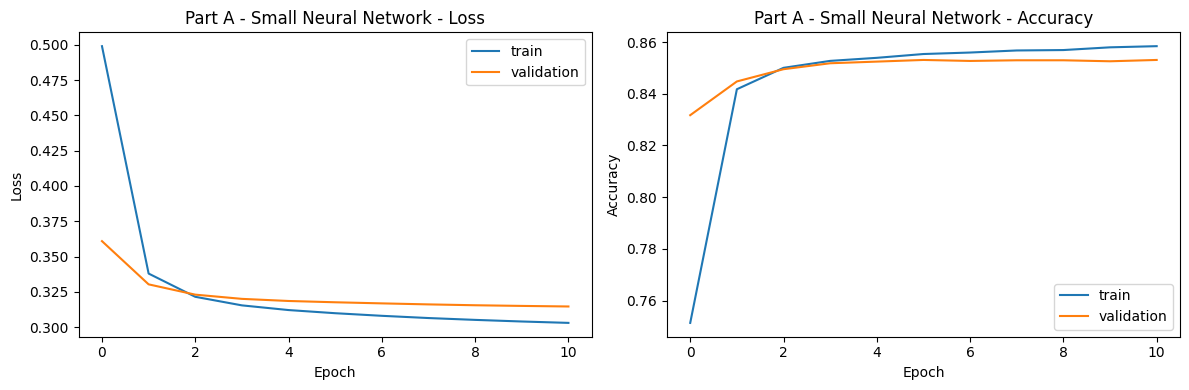

In [ ]:
plot_history(history_a, "Part A - Small Neural Network")

## 10. Evaluate Part A on the Test Data

We use the sklearn **classification report** and **confusion matrix** on the unseen test set.

Classification Report - Part A model
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.91      7431
        >50K       0.74      0.61      0.67      2338

    accuracy                           0.86      9769
   macro avg       0.81      0.77      0.79      9769
weighted avg       0.85      0.86      0.85      9769



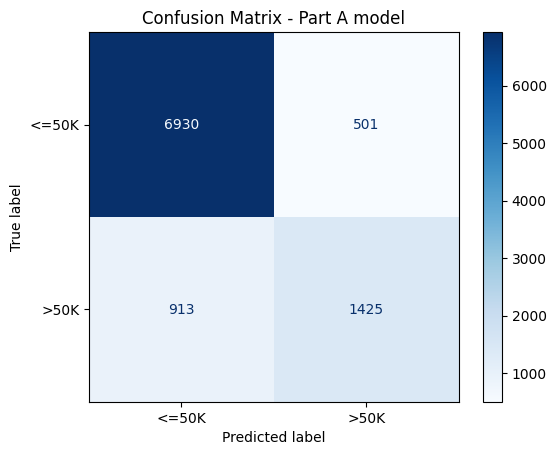

In [ ]:
y_pred_a = evaluate_classifier(model_a, X_test_p, y_test, name="Part A model")

### What we see

The small 1-hidden-layer network reaches around **86% accuracy**. It is good at spotting the `<=50K` group (high recall there), and weaker on the smaller `>50K` group — which is expected, because the dataset is imbalanced (far more people earn `<=50K`).

# Part B — Hyperparameter Tuning with Keras Tuner

## 11. Define the Tunable Model

The Keras Tuner tries many combinations of settings and keeps the best one. We let it tune **4 hyperparameters**:

1. **Number of units** in the hidden layer (16 to 128).
2. **Dropout rate** (0.0 to 0.5) — dropout is a regularization layer that randomly turns off neurons to reduce overfitting.
3. **Optimizer** (`adam` or `rmsprop`).
4. **Learning rate** (0.01, 0.001, or 0.0001) — how big each learning step is.

The `build_model` function below receives an `hp` object and uses it to pick each setting.

In [ ]:
def build_model(hp):
    # 1) number of units in the hidden layer
    units = hp.Int("units", min_value=16, max_value=128, step=16)

    # 2) dropout rate
    dropout_rate = hp.Float("dropout", min_value=0.0, max_value=0.5, step=0.1)

    # 3) optimizer choice
    optimizer_name = hp.Choice("optimizer", ["adam", "rmsprop"])

    # 4) learning rate
    learning_rate = hp.Choice("learning_rate", [1e-2, 1e-3, 1e-4])

    # Build the network (still 1 hidden layer, now with a dropout layer).
    model = Sequential([
        Input(shape=(n_features,)),
        Dense(units, activation="relu"),
        Dropout(dropout_rate),
        Dense(1, activation="sigmoid")
    ])

    # Pick the optimizer with the chosen learning rate.
    if optimizer_name == "adam":
        opt = keras.optimizers.Adam(learning_rate=learning_rate)
    else:
        opt = keras.optimizers.RMSprop(learning_rate=learning_rate)

    model.compile(optimizer=opt, loss="binary_crossentropy", metrics=["accuracy"])
    return model

## 12. Run the Search

We use `RandomSearch`, which tries **6 random combinations** of the settings above. For each one it trains a model (with early stopping) and remembers the **validation accuracy**. The best combination wins.

In [ ]:
tf.keras.utils.set_random_seed(42)

tuner = kt.RandomSearch(
    build_model,
    objective="val_accuracy",
    max_trials=6,                 # try 6 combinations
    executions_per_trial=1,
    directory="kt_dir",
    project_name="adult_income",
    overwrite=True,
    seed=42
)

# Early stopping is used during each trial too.
search_early_stop = EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True)

tuner.search(
    X_train_p, y_train,
    epochs=25,
    validation_split=0.2,
    batch_size=256,
    verbose=0,
    callbacks=[search_early_stop]
)

print("Search finished.")

Search finished.


## 13. Show the Best Hyperparameters

In [ ]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

print("Best hyperparameters found:")
print("  Units        :", best_hp.get("units"))
print("  Dropout rate :", best_hp.get("dropout"))
print("  Optimizer    :", best_hp.get("optimizer"))
print("  Learning rate:", best_hp.get("learning_rate"))

Best hyperparameters found:
  Units        : 64
  Dropout rate : 0.1
  Optimizer    : rmsprop
  Learning rate: 0.001


## 14. Train the Best Model

We rebuild the model using the best settings and train it for the full **50 epochs** (with early stopping and a validation split), exactly like Part A.

Training stopped after 17 epochs


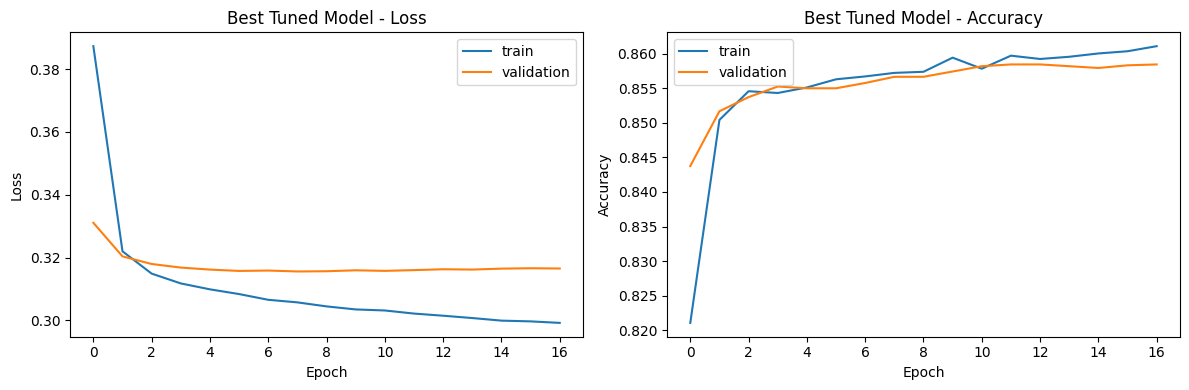

In [ ]:
tf.keras.utils.set_random_seed(42)

best_model = tuner.hypermodel.build(best_hp)

best_early_stop = EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True)

history_best = best_model.fit(
    X_train_p, y_train,
    epochs=50,
    validation_split=0.2,
    batch_size=256,
    verbose=0,
    callbacks=[best_early_stop]
)

print("Training stopped after", len(history_best.history["loss"]), "epochs")
plot_history(history_best, "Best Tuned Model")

# Evaluate the Best Model on Unseen Test Data

## 15. Confusion Matrix and Classification Report

Classification Report - Best Tuned Model
              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      7431
        >50K       0.74      0.63      0.68      2338

    accuracy                           0.86      9769
   macro avg       0.82      0.78      0.80      9769
weighted avg       0.85      0.86      0.86      9769



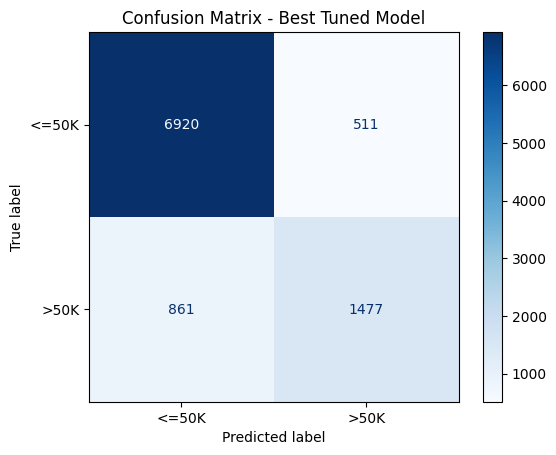

In [ ]:
y_pred_best = evaluate_classifier(best_model, X_test_p, y_test, name="Best Tuned Model")

## 16. Compare Part A vs the Best Tuned Model

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def scores(y_true, y_pred, name):
    return {
        "Model": name,
        "Accuracy":  round(accuracy_score(y_true, y_pred), 4),
        "Precision": round(precision_score(y_true, y_pred), 4),
        "Recall":    round(recall_score(y_true, y_pred), 4),
        "F1":        round(f1_score(y_true, y_pred), 4),
    }

comparison = pd.DataFrame([
    scores(y_test, y_pred_a,    "Part A - Small NN"),
    scores(y_test, y_pred_best, "Best Tuned Model"),
])
comparison

,Model,Accuracy,Precision,Recall,F1
0,Part A - Small NN,0.8553,0.7399,0.6095,0.6684
1,Best Tuned Model,0.8596,0.7430,0.6317,0.6828


### Conclusion

Both models land around **86% accuracy** on the unseen test data. The Keras Tuner searched different combinations of units, dropout, optimizer, and learning rate, and picked the settings that gave the best validation accuracy.

On this dataset the tuned model performs very close to the simple Part A model — the simple network was already a strong baseline. The main value of tuning here is that it found these good settings **automatically** instead of by hand, and the dropout layer helps guard against overfitting.